In [ ]:
# --- Repository root ---------------------------------------------------------
# Every path in this notebook is relative to the repository root, not to notebooks/.
# Resolve the root and work from there, so the notebook behaves the same whether it
# was opened from notebooks/ or from the repository root.
import os
from pathlib import Path

for _d in (Path.cwd(), *Path.cwd().parents):
    if (_d / "processing_scripts").is_dir() and (_d / "README.md").is_file():
        os.chdir(_d)
        break
else:
    raise RuntimeError("repository root not found — open this notebook inside a clone "
                       "of the H3K27me2 repository")
print("working directory:", Path.cwd())

In [1]:
import os
import numpy as np
import pandas as pd
import pyranges as pr
import warnings
from pathlib import Path
import re
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn as sns

from scipy.stats import gaussian_kde
from scipy.stats import spearmanr
from scipy import stats
from tabulate import tabulate
from sklearn.decomposition import PCA
import os
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [4]:
%matplotlib inline
# figure size & color
matplotlib.rcParams['figure.dpi'] = 100 # 150 dpi resolution
matplotlib.rcParams['image.cmap'] = 'Spectral_r' # preferred color map
matplotlib.rcParams['figure.figsize'] = [8, 8] # Square
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


# no bounding boxes or axis:
matplotlib.rcParams['axes.spines.bottom'] = "on"
matplotlib.rcParams['axes.spines.top'] = "on"
matplotlib.rcParams['axes.spines.left'] = "on"
matplotlib.rcParams['axes.spines.right'] = "on"
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [5]:
font = {#'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 15}

matplotlib.rc('font', **font)
matplotlib.rcParams['axes.linewidth'] = 2 #set the value globally

In [6]:
fig_dir = 'figures/'

In [7]:
# --- Directory path ---
dir_path = Path("data/2024/SH_all_data/sections4")

# --- File pattern: match K27ac, K27me1, K27me2, K27me3, P2 with suffix _H.txt or _K.txt or _P.txt ---
file_list = [f for f in dir_path.glob("*.txt") if f.name.startswith(("K27ac","K27me1","K27me2","K27me3","P2")) 
             and f.stem.split("_")[-1] in ["K"]]

# --- Function to read file and add filename as column V2 ---
def read_and_label(file):
    df = pd.read_csv(file, sep="\t", header=None, dtype=str)
    filename = file.stem  # without .txt
    df["V2"] = filename
    return df

# --- Apply to all files ---
dfs = [read_and_label(f) for f in file_list]

# --- Concatenate into one dataframe ---
meta_df = pd.concat(dfs, ignore_index=True)

meta_df['V2'].value_counts()


V2
K27me3_K     17
K27me2_K     17
P2_K         14
K27ac_K      13
K27me1_K     10
K27me1b_K     2
K27me2b_K     2
Name: count, dtype: int64

In [8]:
data_dir = Path("data/2024/cCREs/intersected_annos/FC_out")

# --- meta: make sure we have input_file + meta_assignment ---
meta = meta_df.copy()
rename_map = {}
if 0 in meta.columns: rename_map[0] = "input_file"
if "V1" in meta.columns: rename_map["V1"] = "input_file"
if "V2" in meta.columns: rename_map["V2"] = "meta_assignment"
meta = meta.rename(columns=rename_map)
meta["input_file_norm"] = meta["input_file"].apply(lambda s: Path(str(s)).name)

def read_summary(fp: Path) -> pd.DataFrame:
    df = pd.read_csv(fp, sep="\t", dtype=str)
    if df.columns[0] != "Status":
        df = df.rename(columns={df.columns[0]: "Status"})
    long = df.melt(id_vars=["Status"], var_name="input_file", value_name="count")
    long["count"] = pd.to_numeric(long["count"], errors="coerce").fillna(0).astype("int64")
    long["input_summary_file"] = fp.name
    # parse a readable feature-set label from the filename
    long["features"] = re.sub(r"\.summary\.tsv$", "", fp.name)
    long["input_file_norm"] = long["input_file"].apply(lambda s: Path(str(s)).name)
    return long

summary_files = sorted(data_dir.glob("*.summary.tsv"))
long_df = pd.concat([read_summary(fp) for fp in summary_files], ignore_index=True)

# ---- compute per (features, input_file) ----
totals = (
    long_df
    .groupby(["features", "input_file"], as_index=False)["count"]
    .sum()
    .rename(columns={"count": "total_reads"})
)

assigned = (
    long_df[long_df["Status"] == "Assigned"]
    .groupby(["features", "input_file"], as_index=False)["count"]
    .sum()
    .rename(columns={"count": "reads_in"})
)

per_pair = totals.merge(assigned, on=["features", "input_file"], how="left")
per_pair["reads_in"] = per_pair["reads_in"].fillna(0).astype("int64")
per_pair["fraction_of_reads"] = per_pair["reads_in"] / per_pair["total_reads"].where(per_pair["total_reads"] > 0, 1)
per_pair["input_file_norm"] = per_pair["input_file"].apply(lambda s: Path(str(s)).name)

# ---- join meta (exact, then basename fallback) ----
out = (
    per_pair.merge(meta[["input_file","meta_assignment"]], on="input_file", how="left")
            .merge(meta[["input_file_norm","meta_assignment"]]
                   .rename(columns={"meta_assignment":"meta_assignment_fallback"}),
                   on="input_file_norm", how="left")
)
out["meta_assignment"] = out["meta_assignment"].fillna(out["meta_assignment_fallback"])
out = out.drop(columns=["meta_assignment_fallback"])

# bring along the originating summary filename (for provenance)
src_map = long_df[["features", "input_file", "input_summary_file"]].drop_duplicates()
final_df = (
    out.merge(src_map, on=["features", "input_file"], how="left")
       .loc[:, ["features", "input_file", "reads_in", "total_reads",
                "fraction_of_reads", "meta_assignment", "input_summary_file"]]
       .sort_values(["features", "meta_assignment", "input_file"], na_position="last")
       .reset_index(drop=True)
)

# quick sanity check: compare against raw "Assigned" in one file
# pick one summary file name that exists in your folder:
# final_df.query("input_summary_file == @some_file").head()
# print(final_df.head(12))
final_df["features"] = final_df["input_summary_file"].str.split(".", n=1).str[0]
final_df["meta_assignment"] = final_df["meta_assignment"].str.split("_", n=1).str[0]

In [9]:
import re
import sys
import csv
import warnings
from typing import Optional, Callable
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ===================== Config =====================
data_dir = Path("data/2024/cCREs/intersected_annos/FC_out")
pattern_counts = "*bulk_counts.tsv"   # features × sam matrices
AGG_FN: Callable = pd.DataFrame.mean  # change to pd.DataFrame.sum if you prefer sum aggregation

# Assumes you already have final_df with:
# features, input_file, reads_in, total_reads, fraction_of_reads, meta_assignment, input_summary_file

# ===================== One total_reads + meta per sam (collapsed across feature sets) =====================
totals_per_sam = (
    final_df
    .groupby("input_file", as_index=False)
    .agg({
        "total_reads": "max",
        "meta_assignment": "first"
    })
)
totals_per_sam["input_file_norm"] = totals_per_sam["input_file"].apply(lambda s: Path(str(s)).name)

# Lookup dicts (exact path and basename fallback)
_total_by_exact = dict(zip(totals_per_sam["input_file"], totals_per_sam["total_reads"]))
_total_by_base  = dict(zip(totals_per_sam["input_file_norm"], totals_per_sam["total_reads"]))
_meta_by_exact  = dict(zip(totals_per_sam["input_file"], totals_per_sam["meta_assignment"]))
_meta_by_base   = dict(zip(totals_per_sam["input_file_norm"], totals_per_sam["meta_assignment"]))

def _map_total_from_final(sam_val: str) -> Optional[float]:
    if sam_val in _total_by_exact:
        return _total_by_exact[sam_val]
    base = Path(str(sam_val)).name
    return _total_by_base.get(base, None)

def _map_meta_from_final(sam_val: str) -> Optional[str]:
    if sam_val in _meta_by_exact:
        return _meta_by_exact[sam_val]
    base = Path(str(sam_val)).name
    return _meta_by_base.get(base, None)

# ===================== Reader helpers =====================
def _read_tsv_robust(fp: Path) -> pd.DataFrame:
    # Skip leading blank lines
    with open(fp, "r", encoding="utf-8", errors="ignore") as fh:
        skip = 0
        for line in fh:
            if line.strip() == "":
                skip += 1
                continue
            break
    try:
        return pd.read_csv(fp, sep="\t", engine="c", skiprows=skip, low_memory=False)
    except Exception:
        try:
            csv.field_size_limit(sys.maxsize)
        except Exception:
            csv.field_size_limit(2**31 - 1)
        return pd.read_csv(fp, sep="\t", engine="python", skiprows=skip,
                           quoting=csv.QUOTE_NONE, low_memory=False)

def _normalize_cols_with_feature(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input layout: feature_name, chr, start, end, strand, <samples...>
    Rename to:   feature_id,   chr, start, end, strand, <samples...>
    """
    if df.shape[1] < 6:
        raise ValueError("Counts matrix must have ≥6 columns (feature + 4 genomic + ≥1 sample).")
    cols = list(df.columns)
    # Rename first 5
    cols[0:5] = ["feature_id", "chr", "start", "end", "strand"]
    df.columns = cols
    return df

# ===================== Per-file CPM matrices (rep-level and mark-aggregated) =====================
def process_counts_matrix(fp: Path):
    """
    Returns a tuple (wide_cpm_rep, wide_cpm_mark) where:
      - wide_cpm_rep: chr,start,end,strand,features,source_matrix_file + CPM cols per replicate (e.g., K27ac_r1, K27ac_r2,...)
      - wide_cpm_mark: chr,start,end,strand,features,source_matrix_file + CPM cols aggregated per mark (mean of reps by default)
    Drops any sample columns not present in final_df.
    """
    raw = _read_tsv_robust(fp)
    wide = _normalize_cols_with_feature(raw)

    ann_cols = ["feature_id", "chr", "start", "end", "strand"]
    sample_cols = [c for c in wide.columns if c not in ann_cols]

    # Keep only samples present in final_df (via meta lookup)
    keep_cols = [c for c in sample_cols if _map_meta_from_final(c) is not None]
    if not keep_cols:
        warnings.warn(f"{fp.name}: no sample columns matched final_df; skipping.")
        return None, None

    # Ensure numeric for kept samples
    wide[keep_cols] = wide[keep_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    # Compute CPM using per-sam totals from final_df
    totals_map = {c: _map_total_from_final(c) for c in keep_cols}
    missing_tot = [c for c, t in totals_map.items() if (t is None or t <= 0)]
    if missing_tot:
        warnings.warn(f"{fp.name}: {len(missing_tot)} samples missing totals in final_df; "
                      "they will be normalized with denom=1 (CPM==counts*1e6).")

    denom = {c: (totals_map[c] if (totals_map[c] is not None and totals_map[c] > 0) else 1.0) for c in keep_cols}

    # Build CPM matrix (per-rep, initially with original sample names)
    wide_cpm_rep = wide[ann_cols].copy()
    for c in keep_cols:
        wide_cpm_rep[c] = (wide[c] / denom[c]) * 1e6

    features = re.sub(r"\.bulk_counts\.tsv$", "", fp.name)
    wide_cpm_rep["features"] = features
    wide_cpm_rep["source_matrix_file"] = fp.name

    # Map samples to meta labels and generate replicate indices per mark
    meta_labels = {c: _map_meta_from_final(c) for c in keep_cols}
    rep_counters = defaultdict(int)
    col_rename_rep = {}
    for c in keep_cols:
        mark = meta_labels[c]
        rep_counters[mark] += 1
        col_rename_rep[c] = f"{mark}_r{rep_counters[mark]}"

    # Rename replicate columns to <mark>_r#
    wide_cpm_rep = wide_cpm_rep.rename(columns=col_rename_rep)

    # Reorder columns: annotations first, then features/source, then reps
    rep_cols = [col_rename_rep[c] for c in keep_cols]
    wide_cpm_rep = wide_cpm_rep[ann_cols + ["features", "source_matrix_file"] + rep_cols]

    # Aggregated per-mark (mean across reps by default)
    # Build a frame with only the CPM replicate columns, grouped by mark
    # To aggregate, we need to collect columns by mark
    mark_to_cols = defaultdict(list)
    for c in keep_cols:
        mark_to_cols[meta_labels[c]].append(col_rename_rep[c])

    # Aggregate by column groups
    agg_df = wide_cpm_rep[rep_cols].copy()
    wide_cpm_mark = wide_cpm_rep[ann_cols + ["features", "source_matrix_file"]].copy()
    for mark, cols in mark_to_cols.items():
        # AGG_FN acts across columns (axis=1) for each row
        wide_cpm_mark[mark] = AGG_FN(agg_df[cols], axis=1)

    return wide_cpm_rep, wide_cpm_mark

# ===================== Run all =====================
counts_files = sorted(data_dir.glob(pattern_counts))
if not counts_files:
    raise FileNotFoundError(f"No counts matrices found matching {pattern_counts} in {data_dir}")

per_file_wide_cpm_rep = {}   # dict: features -> wide CPM DF (replicate columns)
per_file_wide_cpm_mark = {}  # dict: features -> wide CPM DF (aggregated per mark)

for fp in counts_files:
    rep_df, mark_df = process_counts_matrix(fp)
    if rep_df is None:
        continue
    feat = rep_df["features"].iloc[0]
    per_file_wide_cpm_rep[feat]  = rep_df
    per_file_wide_cpm_mark[feat] = mark_df

# ===================== Usage (examples) =====================
# keys = list(per_file_wide_cpm_rep.keys())
# per_file_wide_cpm_rep[keys[0]].head()
# per_file_wide_cpm_mark[keys[0]].head()


# summary data

In [10]:
df = per_file_wide_cpm_mark['hg38.gencodev44_HKP_genes-1000_featureCounts_bulk_counts.tsv']
per_file_wide_cpm_mark['hg38.gencodev44_HKP_genes-1000_featureCounts_bulk_counts.tsv'] = df[~pd.to_numeric(df['start'], errors='coerce').isna()]


In [11]:
# effective genome size
hg38_size = 3209286105

# dict to hold expected fractions
expected_fracs = {}

for key, df in per_file_wide_cpm_mark.items():
    # assumes df has 'start' and 'end' columns
    feature_bp = (df['end'].astype(int) - df['start'].astype(int)).sum()
    expected_fracs[key] = feature_bp / hg38_size

expected_df = pd.Series(expected_fracs, name="Expected_Fraction")
print(expected_df)

GRCh38-cCREs.ext500.clean_featureCounts_bulk_counts.tsv         0.164408
K562_allCCREs.ext500.clean_featureCounts_bulk_counts.tsv        0.164408
genes.noPromoters_featureCounts_bulk_counts.tsv                 0.422272
hg38.gencodev44_HKP_genes-1000_featureCounts_bulk_counts.tsv    0.435355
promoters.ext_featureCounts_bulk_counts.tsv                     0.012543
rmsk.noGenes.noCCREs.clean_featureCounts_bulk_counts.tsv        0.223127
Name: Expected_Fraction, dtype: float64


/loc/scratch/48732613/ipykernel_35308/443253323.py:45: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  ax = sns.boxplot(


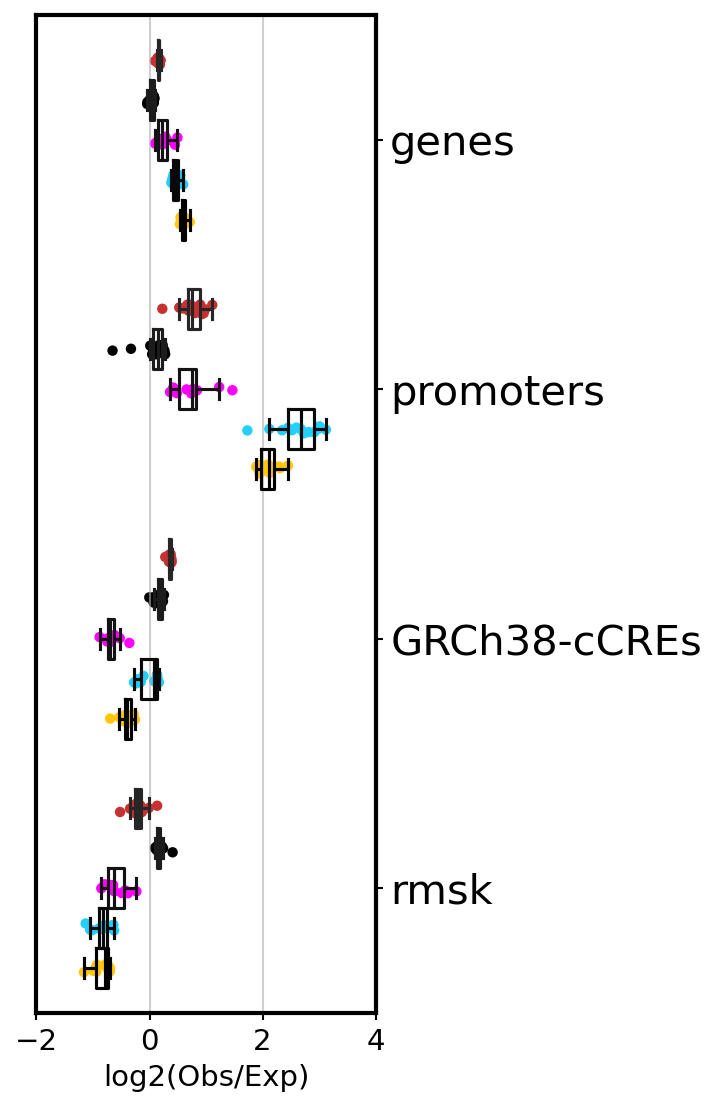

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Config ---
row_colors = ["#C73131", "#000000", "#FF00FF", "#22D0FB", "#FFC60B"]
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]
features_order  = ['genes','promoters','GRCh38-cCREs', 'rmsk']

# --- Map feature name -> expected fraction (from expected_df which is indexed by file names) ---
filekey_for = {
    'genes':       'genes.noPromoters_featureCounts_bulk_counts.tsv',
    'promoters':   'promoters.ext_featureCounts_bulk_counts.tsv',
    'GRCh38-cCREs':'GRCh38-cCREs.ext500.clean_featureCounts_bulk_counts.tsv',
    'rmsk':        'rmsk.noGenes.noCCREs.clean_featureCounts_bulk_counts.tsv',
    'K562_allCCREs':'K562_allCCREs.ext500.clean_featureCounts_bulk_counts.tsv',
}
expected_by_feature = {
    feat: float(expected_df.loc[filekey_for[feat]])
    for feat in filekey_for if filekey_for[feat] in expected_df.index
}

# --- Prepare data ---
plot_df = final_df.copy()
plot_df["meta_assignment"] = pd.Categorical(plot_df["meta_assignment"], categories=marks, ordered=True)
plot_df = plot_df[plot_df["meta_assignment"].notna()]
plot_df = plot_df[plot_df["features"] != "K562_allCCREs"]

# compute Obs/Exp = observed fraction / expected genomic coverage
plot_df["obs_exp"] = np.log2(plot_df["fraction_of_reads"] / plot_df["features"].map(expected_by_feature))

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 2.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "font.size": 14
})

# --- Plot O/E ---
plt.figure(figsize=(5, 7.6))
ax = sns.boxplot(
    data=plot_df,
    y="features",
    x="obs_exp",
    hue="meta_assignment",
    order=features_order,
    hue_order=marks,
    fill=False,
    color="black",
    fliersize=0,
    dodge=True,
    zorder=2,
    legend=False
)

sns.stripplot(
    data=plot_df,
    y="features",
    x="obs_exp",
    hue="meta_assignment",
    order=features_order,
    hue_order=marks,
    palette=dict(zip(marks, row_colors)),
    size=5,
    dodge=True,
    linewidth=0,
    marker="o",
    zorder=1,
    legend=False
)

# Axes, ticks, grid
ax.set_ylabel("")
ax.set_xlabel("log2(Obs/Exp)")
ax.set_xlim(-2,4)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.tick_params(axis='y', labelsize=20)

# choose tick spacing you like; 0.5 works well for O/E
# ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
ax.grid(axis="x", linewidth=1, alpha=0.6, zorder=1)

plt.tight_layout()
plt.show()


/loc/scratch/48732613/ipykernel_35308/2437347241.py:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  ax = sns.barplot(
/loc/scratch/48732613/ipykernel_35308/2437347241.py:31: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.2}` instead.

  ax = sns.barplot(
/loc/scratch/48732613/ipykernel_35308/2437347241.py:83: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


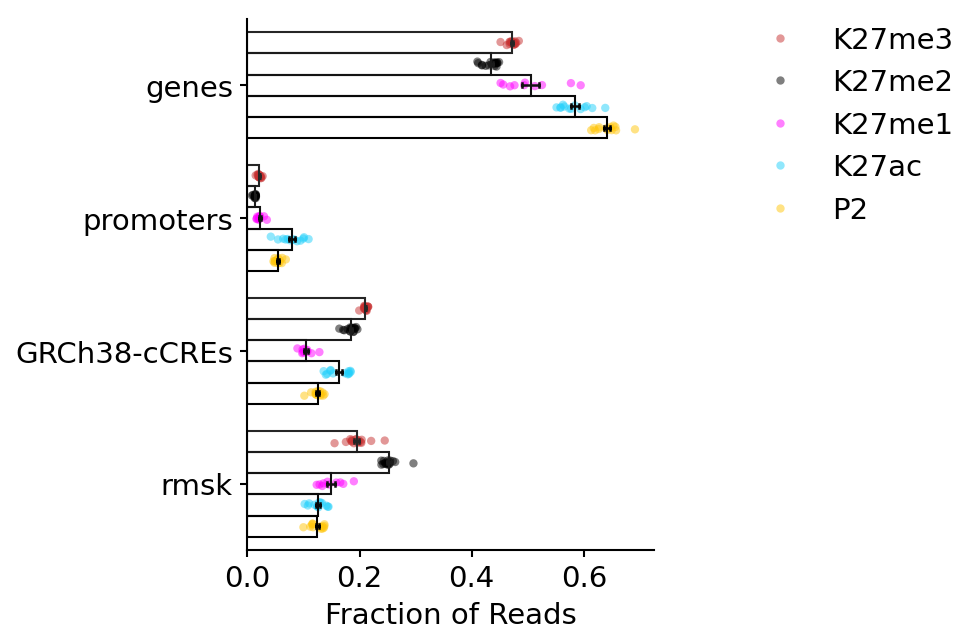

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Config ---
row_colors = ["#C73131", "#000000", "#FF00FF", "#22D0FB", "#FFC60B"]
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]
# features_order  = ['rmsk','GRCh38-cCREs','promoters', 'genes']
features_order  = ['genes','promoters','GRCh38-cCREs', 'rmsk']

# --- Prepare data ---
plot_df = final_df.copy()
plot_df["meta_assignment"] = pd.Categorical(
    plot_df["meta_assignment"], categories=marks, ordered=True
)
plot_df = plot_df[plot_df["meta_assignment"].notna()]
plot_df = plot_df[plot_df["features"] != "K562_allCCREs"]

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "font.size": 14
})

# --- Plot ---
plt.figure(figsize=(3.5, 4.6))
ax = sns.barplot(
    data=plot_df,
    y="features",
    x="fraction_of_reads",
    hue="meta_assignment",
    order=features_order,
    hue_order=marks,
    fill = False,
    color = 'black',
#    palette=dict(zip(marks, row_colors)),
    errorbar="se",    # show mean ± SE
    capsize=0.15,     # little caps on errorbars
    errwidth=1.2,
    dodge=True,
    linewidth = 1,
    zorder=2
)

# Overlay raw points
sns.stripplot(
    data=plot_df,
    y="features",
    x="fraction_of_reads",
    hue="meta_assignment",
    order=features_order,
    hue_order=marks,
    palette=dict(zip(marks, row_colors)),
    size=4,
    dodge=True,
    linewidth=0,
    marker="o",
    alpha=0.5,
    zorder=1
)

# Axis labels, grid, legend
ax.set_ylabel("")
ax.set_xlabel("Fraction of Reads")
# ax.grid(axis="y", linewidth=1, alpha=0.6, zorder=0, ls="--")

# De-duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    frameon=False,
    ncol=1,
    loc="center right",
    bbox_to_anchor=(1.8, 0.8)
)

plt.tight_layout()
plt.show()


/loc/scratch/48732613/ipykernel_35308/1737324368.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["meta_assignment", "features"], as_index=False)["fraction_of_reads"]


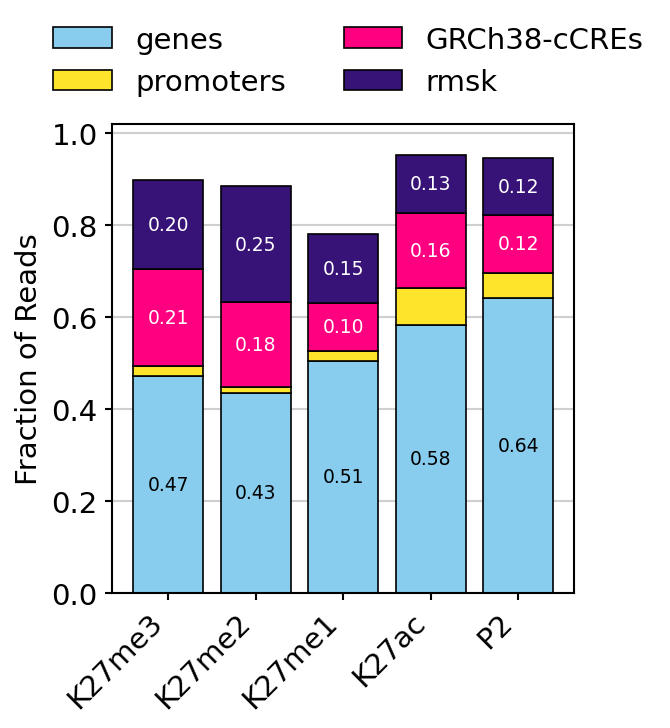

In [14]:
# --- Inputs / config (same as your snippet) ---
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]   # x-axis order
exclude_feature = "K562_allCCREs"
normalize_per_mark = True

# Style for features (same palette/order used before)
features_order  = ['genes','promoters','GRCh38-cCREs','rmsk']
#features_order  = ['rmsk','GRCh38-cCREs','promoters', 'genes']

region_colors   = ["#88CCEE", "#FEE52C", "#ff0080", "#371377"]     # maps to features_order
#region_colors   = ["#371377","#ff0080", "#FEE52C","#88CCEE", ]     # maps to features_order

# --- Prep data (unchanged logic) ---
plot_df = final_df.copy()
plot_df = plot_df[plot_df["meta_assignment"].notna()]
plot_df = plot_df[plot_df["features"] != exclude_feature]
plot_df["meta_assignment"] = pd.Categorical(plot_df["meta_assignment"], categories=marks, ordered=True)

agg = (
    plot_df
    .groupby(["meta_assignment", "features"], as_index=False)["fraction_of_reads"]
    .mean()
)

# if normalize_per_mark:
#     agg["fraction_of_reads"] = (
#         agg.groupby("meta_assignment")["fraction_of_reads"]
#            .transform(lambda x: x / x.sum() if x.sum() != 0 else x)
#     )

# pivot to wide for stacked plotting; enforce mark & feature order
wide = agg.pivot(index="meta_assignment", columns="features", values="fraction_of_reads")
wide = wide.reindex(index=marks)                     # marks (x) order
wide = wide.reindex(columns=features_order)          # features (stack) order
wide = wide.fillna(0.0)

# color map for stacks
feat2color = dict(zip(features_order, region_colors))

# --- Plot (formatting only) ---
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "font.size": 14
})

fig, ax = plt.subplots(figsize=(3.5, 4.6), constrained_layout=False)

xpos   = np.arange(len(wide.index))
width  = 0.8
bottom = np.zeros(len(wide.index))

# stacked bars in the specified feature order
for feat in features_order:
    vals = wide[feat].values
    ax.bar(
        xpos, vals,
        bottom=bottom,
        label=feat,
        color=feat2color[feat],
        edgecolor="black",
        linewidth=0.8,
        width=width
    )
    bottom = bottom + vals

# annotate any segment > 0.10 with contrasting text color
bottom = np.zeros(len(wide.index))
for feat in features_order:
    vals = wide[feat].values
    centers = bottom + vals/2
    # genes = black text, others = white (to match your prior style)
    txt_color = 'black' if feat == 'genes' else 'white'
    for i, h in enumerate(vals):
        if h > 0.10:
            ax.text(
                xpos[i], centers[i],
                f"{h:.2f}",
                ha='center', va='center',
                color=txt_color, fontsize=9
            )
    bottom += vals

# cosmetics
ax.set_xlabel("")
ax.set_ylabel("Fraction of Reads")
ax.set_ylim(0, 1.02 if normalize_per_mark else max(1.02, float(wide.sum(axis=1).max()) * 1.05))
ax.set_xticks(xpos)
ax.set_xticklabels(wide.index, rotation=45, ha='right')
ax.grid(axis='y', linewidth=1, alpha=0.6)
ax.set_axisbelow(True)
# ax.set_title("Fraction of Reads per Mark, stacked by feature", pad=6)

# legend below the plot, shared
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='',
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.55, 1.08),
    frameon=False
)

# leave room for legend
plt.subplots_adjust(bottom=0.22, left=0.10, right=0.98, top=0.90)
plt.show()


# feature heatmps

/loc/scratch/48732613/ipykernel_35308/3665355026.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


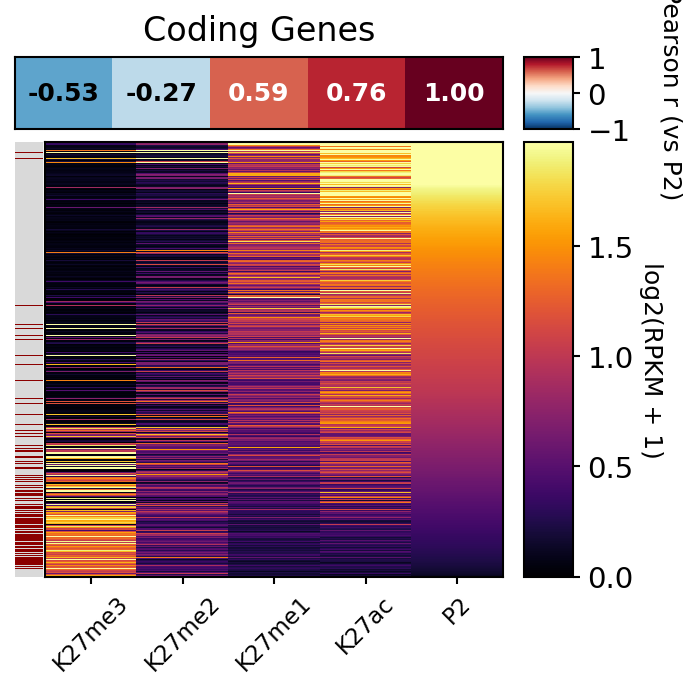

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ---------------- inputs ----------------
files = [
    'hg38.gencodev44_HKP_genes-1000_featureCounts_bulk_counts.tsv'
]
titles = ['Coding Genes']
thresh = 1
color_map = 'inferno'
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]

# ---------------- load shape categories ----------------
cats = pd.read_csv(
    'data/2024/LAD_data/JG_coding_genes_maxRPKM.tsv',
    sep='\t',
    index_col='Geneid'
)

# normalize IDs (strip version suffix if present)
cats.index = cats.index.astype(str).str.replace(r"\..*$", "", regex=True)
shape_map = cats['shape_category'].astype(str)

ME3_LABEL = "me3_domain"  # change if your category string differs

# ---------------- helpers ----------------
def _is_int_str(s):
    s = str(s)
    return s.isdigit()

def _strip_version(ids):
    return pd.Index(pd.Series(ids, dtype=str).str.replace(r"\..*$", "", regex=True).values)

def prepare_matrix_from_key(key):
    """Return (df_log_rpkm, corr_vec_row, present_marks_list, n_features) for one file key."""
    df = per_file_wide_cpm_mark[key].copy()

    for col in ("chr", "start", "end"):
        if col not in df.columns:
            raise KeyError(f"[{key}] missing required column: {col}")

    present = [m for m in marks if m in df.columns]
    if not present:
        raise ValueError(f"[{key}] none of the requested marks are present: {marks}")
    if "P2" not in present:
        raise KeyError(f"[{key}] P2 column not found; required for the correlation strip.")

    mask_clean = df["start"].apply(_is_int_str) & df["end"].apply(_is_int_str)
    df = df.loc[mask_clean].copy()
    df["start"] = df["start"].astype(int)
    df["end"]   = df["end"].astype(int)
    df["length_bp"] = df["end"] - df["start"]
    df = df.loc[df["length_bp"] > 0].copy()

    df[present] = df[present].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    
    rpkm_linear = (df[present].T / df["length_bp"].to_numpy()).T * 1000.0

    keep_mask = rpkm_linear.max(axis=1) >= thresh
    df = df.loc[keep_mask].copy()
    
    rpkm_linear = rpkm_linear.loc[keep_mask]

    if "feature_id" in df.columns:
        feature_labels = df["feature_id"].astype(str)
    else:
        feature_labels = df["chr"].astype(str) + ":" + df["start"].astype(str) + "-" + df["end"].astype(str)

    feature_labels = feature_labels.loc[~feature_labels.str.startswith(("TAF11L", "FAM90A", "USP17L"))]
    df = df.loc[feature_labels.index].copy()
    rpkm_linear = rpkm_linear.loc[feature_labels.index]

    log_rpkm = np.log2(rpkm_linear + 1)
    df_log = pd.DataFrame(log_rpkm.values, index=feature_labels.values, columns=present)

    df_log = df_log.sort_values(by="P2", ascending=False, na_position="last")

    corr_series = df_log[present].corr(method="pearson")["P2"]
    corr_vec = corr_series.loc[present].to_numpy()[np.newaxis, :]

    return df_log, corr_vec, present, df_log.shape[0]

# ---------------- collect panels (global vmin/vmax) ----------------
panel_tables   = []
panel_corrs    = []
panel_marks    = []
panel_nfeats   = []

for key in files:
    df_log, corr_vec, present_list, nfeat = prepare_matrix_from_key(key)
    panel_tables.append(df_log)
    panel_corrs.append(corr_vec)
    panel_marks.append(present_list)
    panel_nfeats.append(nfeat)

all_vals = np.concatenate([t.values.flatten() for t in panel_tables])
vmin = np.nanmin(all_vals)
vmax = np.nanpercentile(all_vals, 95)

# ---------------- layout ----------------
TOP_H, BOTTOM_H = 3.0, 18.0
n_panels = len(files)

fig = plt.figure(figsize=(2.8*n_panels + 2, 4.5))
gs = GridSpec(
    nrows=2,
    ncols=n_panels + 1,   # last col = colorbars
    width_ratios=[20]*n_panels + [2.0],
    height_ratios=[TOP_H, BOTTOM_H],
    hspace=0.05, wspace=0.08,
    figure=fig
)

cmap_corr = plt.get_cmap("RdBu_r")
norm_corr = plt.Normalize(-1, 1)

# boolean side-bar cmap (0/1)
bool_cmap = ListedColormap(["#d9d9d9", "#8B0000"])
bool_norm = BoundaryNorm([-0.5, 0.5, 1.5], bool_cmap.N)

for j in range(n_panels):
    df_log = panel_tables[j]
    corr_vec = panel_corrs[j]
    present_j = panel_marks[j]
    title_j = titles[j]

    # --- top: Pearson vs P2 strip ---
    ax_top = fig.add_subplot(gs[0, j])
    ax_top.imshow(corr_vec, aspect="auto", interpolation="nearest",
                  cmap=cmap_corr, vmin=-1, vmax=1)
    ax_top.set_yticks([])
    ax_top.set_xticks([])
    ax_top.set_xticklabels([])
    ax_top.set_title(title_j, pad=8, fontsize=16)

    corr_series = df_log[present_j].corr(method="pearson")["P2"]
    for k, m in enumerate(present_j):
        r = corr_series.loc[m]
        rgba = cmap_corr(norm_corr(r))
        lum = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
        txt_color = "black" if lum > 0.55 else "white"
        ax_top.text(k, 0, f"{r:.2f}", ha="center", va="center",
                    fontsize=12, fontweight="bold", color=txt_color)

    # --- bottom: main heatmap + boolean side bar (me3_domain) ---
    ax = fig.add_subplot(gs[1, j])

    # align df_log index to cats (strip version suffix)
    idx_clean = _strip_version(df_log.index)
    is_me3 = (shape_map.reindex(idx_clean).fillna("").values == ME3_LABEL).astype(int)  # (n,)
    is_me3 = is_me3.reshape(-1, 1)  # (n,1)

    divider = make_axes_locatable(ax)
    ax_bool = divider.append_axes("left", size="6%", pad=0.02)
    ax_bool.imshow(is_me3, aspect="auto", interpolation="nearest", cmap=bool_cmap, norm=bool_norm)
    ax_bool.set_xticks([])
    ax_bool.set_yticks([])
    for sp in ax_bool.spines.values():
        sp.set_visible(False)
    ax_bool.set_title('')

    M = df_log[present_j].values
    ax.imshow(M, aspect="auto", interpolation="nearest",
              cmap=color_map, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(present_j)))
    ax.set_xticklabels(present_j, rotation=45, fontsize=11)
    ax.set_yticks([])
    ax.set_ylabel("")

# ---------------- shared colorbars on the right ----------------
cax_corr = fig.add_subplot(gs[0, -1])
cbar_top = plt.colorbar(plt.cm.ScalarMappable(norm=norm_corr, cmap=cmap_corr),
                        cax=cax_corr, orientation="vertical")
cbar_top.set_ticks([-1, 0, 1])
cbar_top.set_label("Pearson r (vs P2)", rotation=270, labelpad=25, fontsize=12)

cax_main = fig.add_subplot(gs[1, -1])
cbar_main = plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=color_map),
                         cax=cax_main)
cbar_main.set_label("log2(RPKM + 1)", rotation=270, labelpad=14, fontsize=12)

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "20260205_Fig1c_coding_genes_RPKM_heatmap.pdf"), bbox_inches="tight")

plt.show()


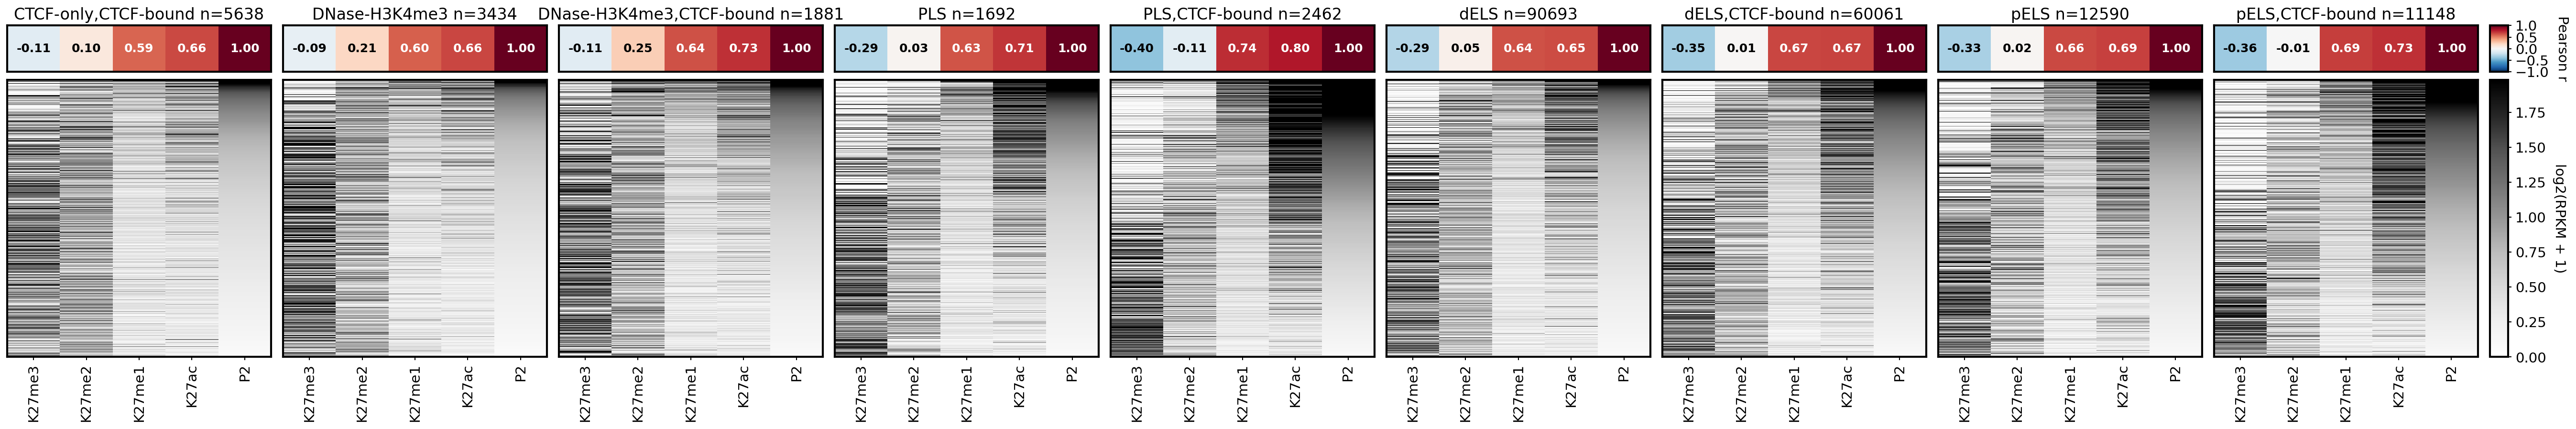

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

thresh = 1
color_map = 'Greys'
# ---------------- load data ----------------
df_mark = per_file_wide_cpm_mark['GRCh38-cCREs.ext500.clean_featureCounts_bulk_counts.tsv'].copy()

# ---------------- settings ----------------
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]
present_marks = [m for m in marks if m in df_mark.columns]
if not present_marks:
    raise ValueError("None of the requested marks are present.")
if "P2" not in present_marks:
    raise KeyError("P2 column not found; required for correlation strip.")

# ---------------- clean coords ----------------
def _is_int_str(s):
    s = str(s)
    return s.isdigit()

mask_clean = df_mark["start"].apply(_is_int_str) & df_mark["end"].apply(_is_int_str)
df_clean = df_mark.loc[mask_clean].copy()
df_clean["start"] = df_clean["start"].astype(int)
df_clean["end"]   = df_clean["end"].astype(int)
df_clean["length_bp"] = df_clean["end"] - df_clean["start"]
df_clean = df_clean.loc[df_clean["length_bp"] > 0].copy()

# ---------------- CPM → RPKM (linear) ----------------
df_clean[present_marks] = df_clean[present_marks].apply(pd.to_numeric, errors="coerce").fillna(0.0)
rpkm_linear = (df_clean[present_marks].T / df_clean["length_bp"].to_numpy()).T * 1000.0

# ---------------- threshold: keep rows where any mark >= 1 ----------------
keep_mask = rpkm_linear.max(axis=1) >= thresh
df_clean = df_clean.loc[keep_mask].copy()
rpkm_linear = rpkm_linear.loc[keep_mask]

# ---------------- log2(RPKM+1) ----------------
df_rpkm = df_clean.copy()
df_rpkm[present_marks] = np.log2(rpkm_linear + 1.0)

# ---------------- feature labels ----------------
feature_labels = df_clean["feature_id"].astype(str) if "feature_id" in df_clean.columns else \
                 df_clean["chr"].astype(str) + ":" + df_clean["start"].astype(str) + "-" + df_clean["end"].astype(str)

df_log_rpkm_all = pd.DataFrame(df_rpkm[present_marks].values,
                               index=feature_labels, columns=present_marks)

# ---------------- categories from feature_id ----------------
cat_series = (
    df_clean["feature_id"].astype(str)
             .str.split("_", n=1).str[1]
             .str.split("_", n=1).str[0]
)
cats_by_feature = pd.Series(cat_series.values, index=feature_labels)

# ---------------- shared color scale ----------------
vmin = np.nanmin(df_log_rpkm_all.values)
vmax = np.nanpercentile(df_log_rpkm_all.values, 95)

# ---------------- figure layout ----------------
categories = sorted(cats_by_feature.unique())
n_cats = len(categories)

fig = plt.figure(figsize=(5 * n_cats, 6))
outer_gs = GridSpec(2, n_cats + 1, width_ratios=[20] * n_cats + [1.4],
                    height_ratios=[3, 18], hspace=0.05, wspace=0.05, figure=fig)

ims, ims_corr = [], []

for i, cat in enumerate(categories):
    feats = cats_by_feature.index[cats_by_feature == cat]
    df_cat = df_log_rpkm_all.loc[feats, present_marks].dropna(how="all")
    if df_cat.empty or "P2" not in df_cat.columns:
        continue

    df_cat = df_cat.sort_values(by="P2", ascending=False, na_position="last")
    M = df_cat.values

    # correlation strip
    corr_series = df_cat[present_marks].corr(method="pearson")["P2"]
    corr_vec = corr_series.loc[present_marks].to_numpy()[np.newaxis, :]

    ax_top = fig.add_subplot(outer_gs[0, i])
    im_corr = ax_top.imshow(corr_vec, aspect="auto", cmap="RdBu_r",
                            vmin=-1, vmax=1, interpolation="nearest")
    ax_top.set_yticks([])
    ax_top.set_xticks([])
    ax_top.set_title(f"{cat} n={df_cat.shape[0]}", fontsize=16)

    # annotate r values
    norm_corr = plt.Normalize(-1, 1)
    cmap_corr = plt.get_cmap("RdBu_r")
    for j, m in enumerate(present_marks):
        r = corr_series.loc[m]
        rgba = cmap_corr(norm_corr(r))
        lum = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
        txt_color = "black" if lum > 0.55 else "white"
        ax_top.text(j, 0, f"{r:.2f}", ha="center", va="center",
                    fontsize=12, fontweight="bold", color=txt_color)

    # main heatmap
    ax_bot = fig.add_subplot(outer_gs[1, i])
    im = ax_bot.imshow(M, aspect="auto", cmap=color_map,
                       vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_bot.set_xticks(np.arange(len(present_marks)))
    ax_bot.set_xticklabels(present_marks, rotation=90)
    ax_bot.set_yticks([])
    ax_bot.set_ylabel(f"")

    ims.append(im)
    ims_corr.append(im_corr)

# ---------------- single colorbars ----------------
cax_corr = fig.add_subplot(outer_gs[0, -1])
cax_main = fig.add_subplot(outer_gs[1, -1])

cbar_corr = plt.colorbar(ims_corr[0], cax=cax_corr, orientation="vertical")
cbar_corr.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar_corr.set_label("Pearson r", rotation=270, labelpad=20)

cbar_main = plt.colorbar(ims[0], cax=cax_main)
cbar_main.set_label("log2(RPKM + 1)", rotation=270, labelpad=20)

# plt.tight_layout()
plt.show()


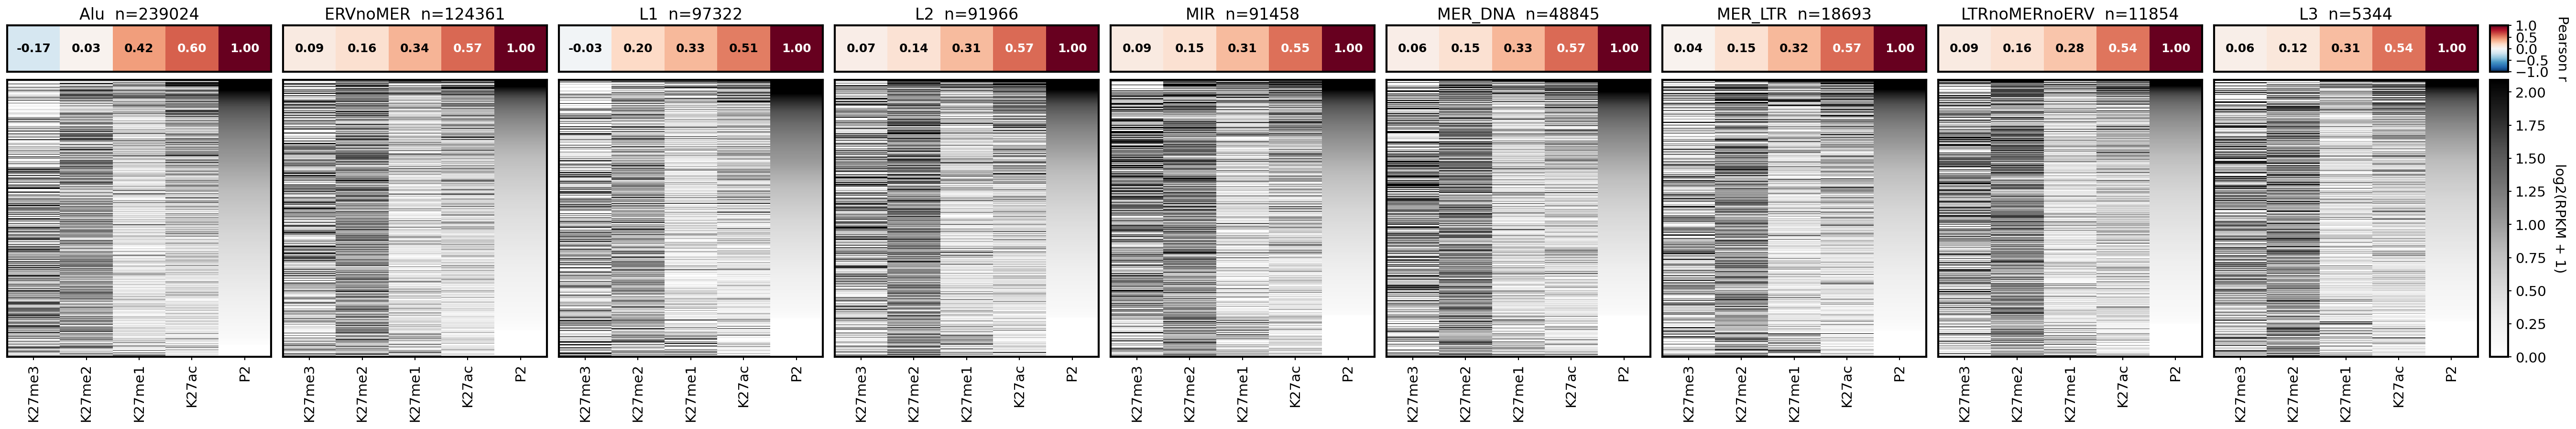

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

thresh = 1
color_map = 'Greys'
# ---------------- load data ----------------
df_mark = per_file_wide_cpm_mark['rmsk.noGenes.noCCREs.clean_featureCounts_bulk_counts.tsv'].copy()

# ---------------- settings ----------------
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "P2"]
present_marks = [m for m in marks if m in df_mark.columns]
if not present_marks:
    raise ValueError("None of the requested marks are present.")
if "P2" not in present_marks:
    raise KeyError("P2 column not found; required for correlation strip.")

# ---------------- clean coords ----------------
def _is_int_str(s):
    s = str(s)
    return s.isdigit()

mask_clean = df_mark["start"].apply(_is_int_str) & df_mark["end"].apply(_is_int_str)
df_clean = df_mark.loc[mask_clean].copy()
df_clean["start"] = df_clean["start"].astype(int)
df_clean["end"]   = df_clean["end"].astype(int)
df_clean["length_bp"] = df_clean["end"] - df_clean["start"]
df_clean = df_clean.loc[df_clean["length_bp"] > 0].copy()

# ---------------- CPM → RPKM (linear) ----------------
df_clean[present_marks] = df_clean[present_marks].apply(pd.to_numeric, errors="coerce").fillna(0.0)
rpkm_linear = (df_clean[present_marks].T / df_clean["length_bp"].to_numpy()).T * 1000.0

# ---------------- threshold: keep rows where any mark >= 1 ----------------
keep_mask = rpkm_linear.max(axis=1) >= 1.0
df_clean = df_clean.loc[keep_mask].copy()
rpkm_linear = rpkm_linear.loc[keep_mask]

# ---------------- log2(RPKM+1) ----------------
df_rpkm = df_clean.copy()
df_rpkm[present_marks] = np.log2(rpkm_linear + 1.0)

# ---------------- feature labels ----------------
feature_labels = (
    df_clean["feature_id"].astype(str)
    if "feature_id" in df_clean.columns
    else df_clean["chr"].astype(str) + ":" + df_clean["start"].astype(str) + "-" + df_clean["end"].astype(str)
)

df_log_rpkm_all = pd.DataFrame(df_rpkm[present_marks].values,
                               index=feature_labels, columns=present_marks)

# ---------------- categories from feature_id (dot-split; take field 3) ----------------
if "feature_id" not in df_clean.columns:
    raise KeyError("feature_id column required to derive categories from dot-split.")

# Parse the 4th token (0-based index 3) after splitting on '.'
cat_series = (
    df_clean["feature_id"].astype(str)
           .str.split('.', n=4)
           .str.get(3)
           .fillna("NA")
)

# Map each feature to its category
cats_by_feature = pd.Series(cat_series.values, index=feature_labels)

# Order categories by frequency (value_counts)
cat_counts = cat_series.value_counts()
categories = list(cat_counts.index)

# ---------------- shared color scale ----------------
vmin = np.nanmin(df_log_rpkm_all.values)
vmax = np.nanpercentile(df_log_rpkm_all.values, 95)

# ---------------- figure layout ----------------
n_cats = len(categories)
fig = plt.figure(figsize=(5 * n_cats, 6))
outer_gs = GridSpec(2, n_cats + 1, width_ratios=[20] * n_cats + [1.4],
                    height_ratios=[3, 18], hspace=0.05, wspace=0.05, figure=fig)

ims, ims_corr = [], []
cmap_corr = plt.get_cmap("RdBu_r")
norm_corr = plt.Normalize(-1, 1)

for i, cat in enumerate(categories):
    feats = cats_by_feature.index[cats_by_feature == cat]
    df_cat = df_log_rpkm_all.loc[feats, present_marks].dropna(how="all")
    if df_cat.empty or "P2" not in df_cat.columns:
        continue

    df_cat = df_cat.sort_values(by="P2", ascending=False, na_position="last")
    M = df_cat.values

    # correlation strip
    corr_series = df_cat[present_marks].corr(method="pearson")["P2"]
    corr_vec = corr_series.loc[present_marks].to_numpy()[np.newaxis, :]

    ax_top = fig.add_subplot(outer_gs[0, i])
    im_corr = ax_top.imshow(corr_vec, aspect="auto", cmap="RdBu_r",
                            vmin=-1, vmax=1, interpolation="nearest")
    ax_top.set_yticks([])
    ax_top.set_xticks([])
    # Use count from value_counts for consistent n (should match df_cat.shape[0])
    n_here = int(cat_counts.get(cat, df_cat.shape[0]))
    ax_top.set_title(f"{cat}  n={n_here}", fontsize=16)

    # annotate r values
    for j, m in enumerate(present_marks):
        r = corr_series.loc[m]
        rgba = cmap_corr(norm_corr(r))
        lum = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
        txt_color = "black" if lum > 0.55 else "white"
        ax_top.text(j, 0, f"{r:.2f}", ha="center", va="center",
                    fontsize=12, fontweight="bold", color=txt_color)

    # main heatmap
    ax_bot = fig.add_subplot(outer_gs[1, i])
    im = ax_bot.imshow(M, aspect="auto", cmap=color_map,
                       vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_bot.set_xticks(np.arange(len(present_marks)))
    ax_bot.set_xticklabels(present_marks, rotation=90)
    ax_bot.set_yticks([])
    ax_bot.set_ylabel("")

    ims.append(im)
    ims_corr.append(im_corr)

# ---------------- single colorbars ----------------
if ims_corr:
    cax_corr = fig.add_subplot(outer_gs[0, -1])
    cbar_corr = plt.colorbar(ims_corr[0], cax=cax_corr, orientation="vertical")
    cbar_corr.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar_corr.set_label("Pearson r", rotation=270, labelpad=20)

if ims:
    cax_main = fig.add_subplot(outer_gs[1, -1])
    cbar_main = plt.colorbar(ims[0], cax=cax_main)
    cbar_main.set_label("log2(RPKM + 1)", rotation=270, labelpad=20)

plt.show()
